# Exploratory Data Analysis

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bioacoustics.data import load_results, load_metadata

import bioacoustics.visualization as viz
viz.set_style()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
data_train = load_results("features", "data_train")
data_train_soundscapes = load_results("features", "data_train_soundscapes")
_, _, df_taxonomy = load_metadata()
primary_to_class = dict(zip(df_taxonomy["primary_label"], df_taxonomy["class_name"]))

Here, analyze collected features (do dimension reduction, etc.). Analyze species presence, class balance...

In [41]:
data_train["y_class"].value_counts()

Amphibia  Aves  Insecta  Mammalia  Reptilia
0         1     0        0         0           32254
1         0     0        0         0             422
0         0     1        0         0             192
                0        1         0              79
                         0         1               1
Name: count, dtype: int64

In [42]:
data_train_soundscapes["y_class"].value_counts()

Amphibia  Aves  Insecta  Mammalia  Reptilia
1         0     0        0         0           433
          1     0        0         0            94
0         1     1        0         0            81
          0     1        0         0            39
1         0     1        0         0            23
0         1     0        0         0            15
1         1     0        1         0            13
0         0     0        1         0            12
                1        1         0            11
                         0         1             6
          1     1        0         1             6
1         0     0        1         0             2
0         1     0        1         0             2
1         1     1        0         0             1
0         0     1        1         1             1
Name: count, dtype: int64

In [43]:
data_train["metadata"]

,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,collection
filename,,,,,,,,,,,,,
1161364/iNat1216197.ogg,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,iNat
1161364/iNat1114648.ogg,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,iNat
1161364/iNat810195.ogg,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,iNat
1161364/iNat818781.ogg,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,iNat
1161364/iNat556514.ogg,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,iNat
...,...,...,...,...,...,...,...,...,...,...,...,...,...
yeofly1/XC762473.ogg,[],['call'],-6.7281,-76.4181,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/762473/download,XC
yeofly1/XC818328.ogg,[],"['call', ' song']",-16.0538,-49.6040,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,5.0,https://xeno-canto.org/818328/download,XC
yeofly1/XC425545.ogg,[],['song'],5.9002,-74.8485,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Jerome Fischer,by-nc-sa,4.0,https://xeno-canto.org/425545/download,XC


Distribution of `data_train` and `data_train_soundscapes`

In [44]:
data_train["y_class"]

,Amphibia,Aves,Insecta,Mammalia,Reptilia
filename,,,,,
1161364/iNat1216197.ogg,0,0,1,0,0
1161364/iNat1114648.ogg,0,0,1,0,0
1161364/iNat810195.ogg,0,0,1,0,0
1161364/iNat818781.ogg,0,0,1,0,0
1161364/iNat556514.ogg,0,0,1,0,0
...,...,...,...,...,...
yeofly1/XC762473.ogg,0,1,0,0,0
yeofly1/XC818328.ogg,0,1,0,0,0
yeofly1/XC425545.ogg,0,1,0,0,0


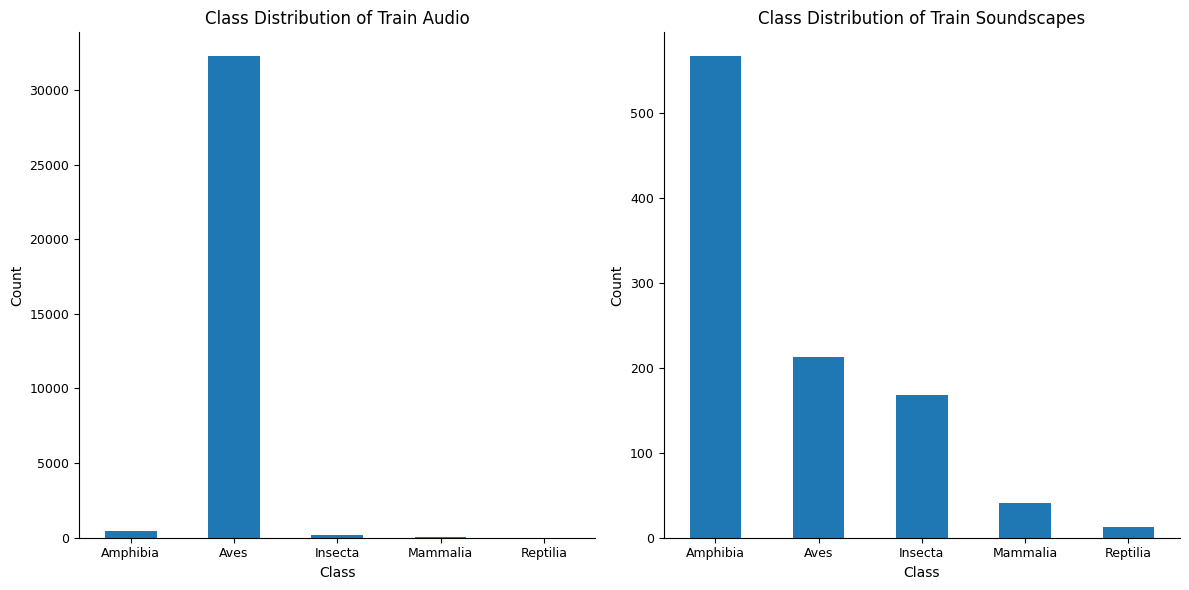

In [45]:
viz.plot_class_distribution(data_train, data_train_soundscapes)

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97710/1561592154.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  viz.plot_species_distribution(data_train["y_primary"].sum(0), data_train_soundscapes["y_primary"].sum(0),primary_to_class)


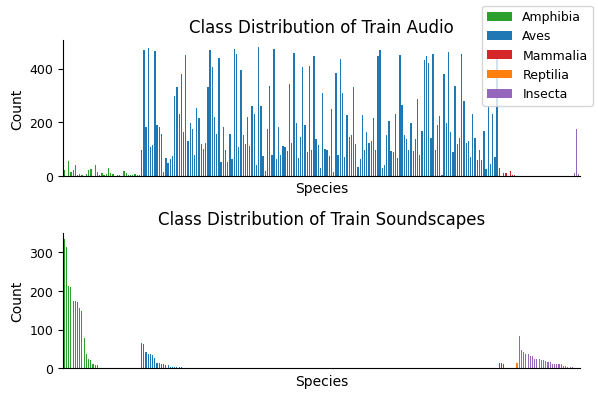

In [62]:
viz.plot_species_distribution(data_train["y_primary"].sum(0), data_train_soundscapes["y_primary"].sum(0),primary_to_class)

We see that the distribution between `train_audio` and `train_soundscapes` is very different, so we need to be careful when we work between them.

Correlation matrix

In [47]:
corr_matrix = data_train_soundscapes["X"].corr()

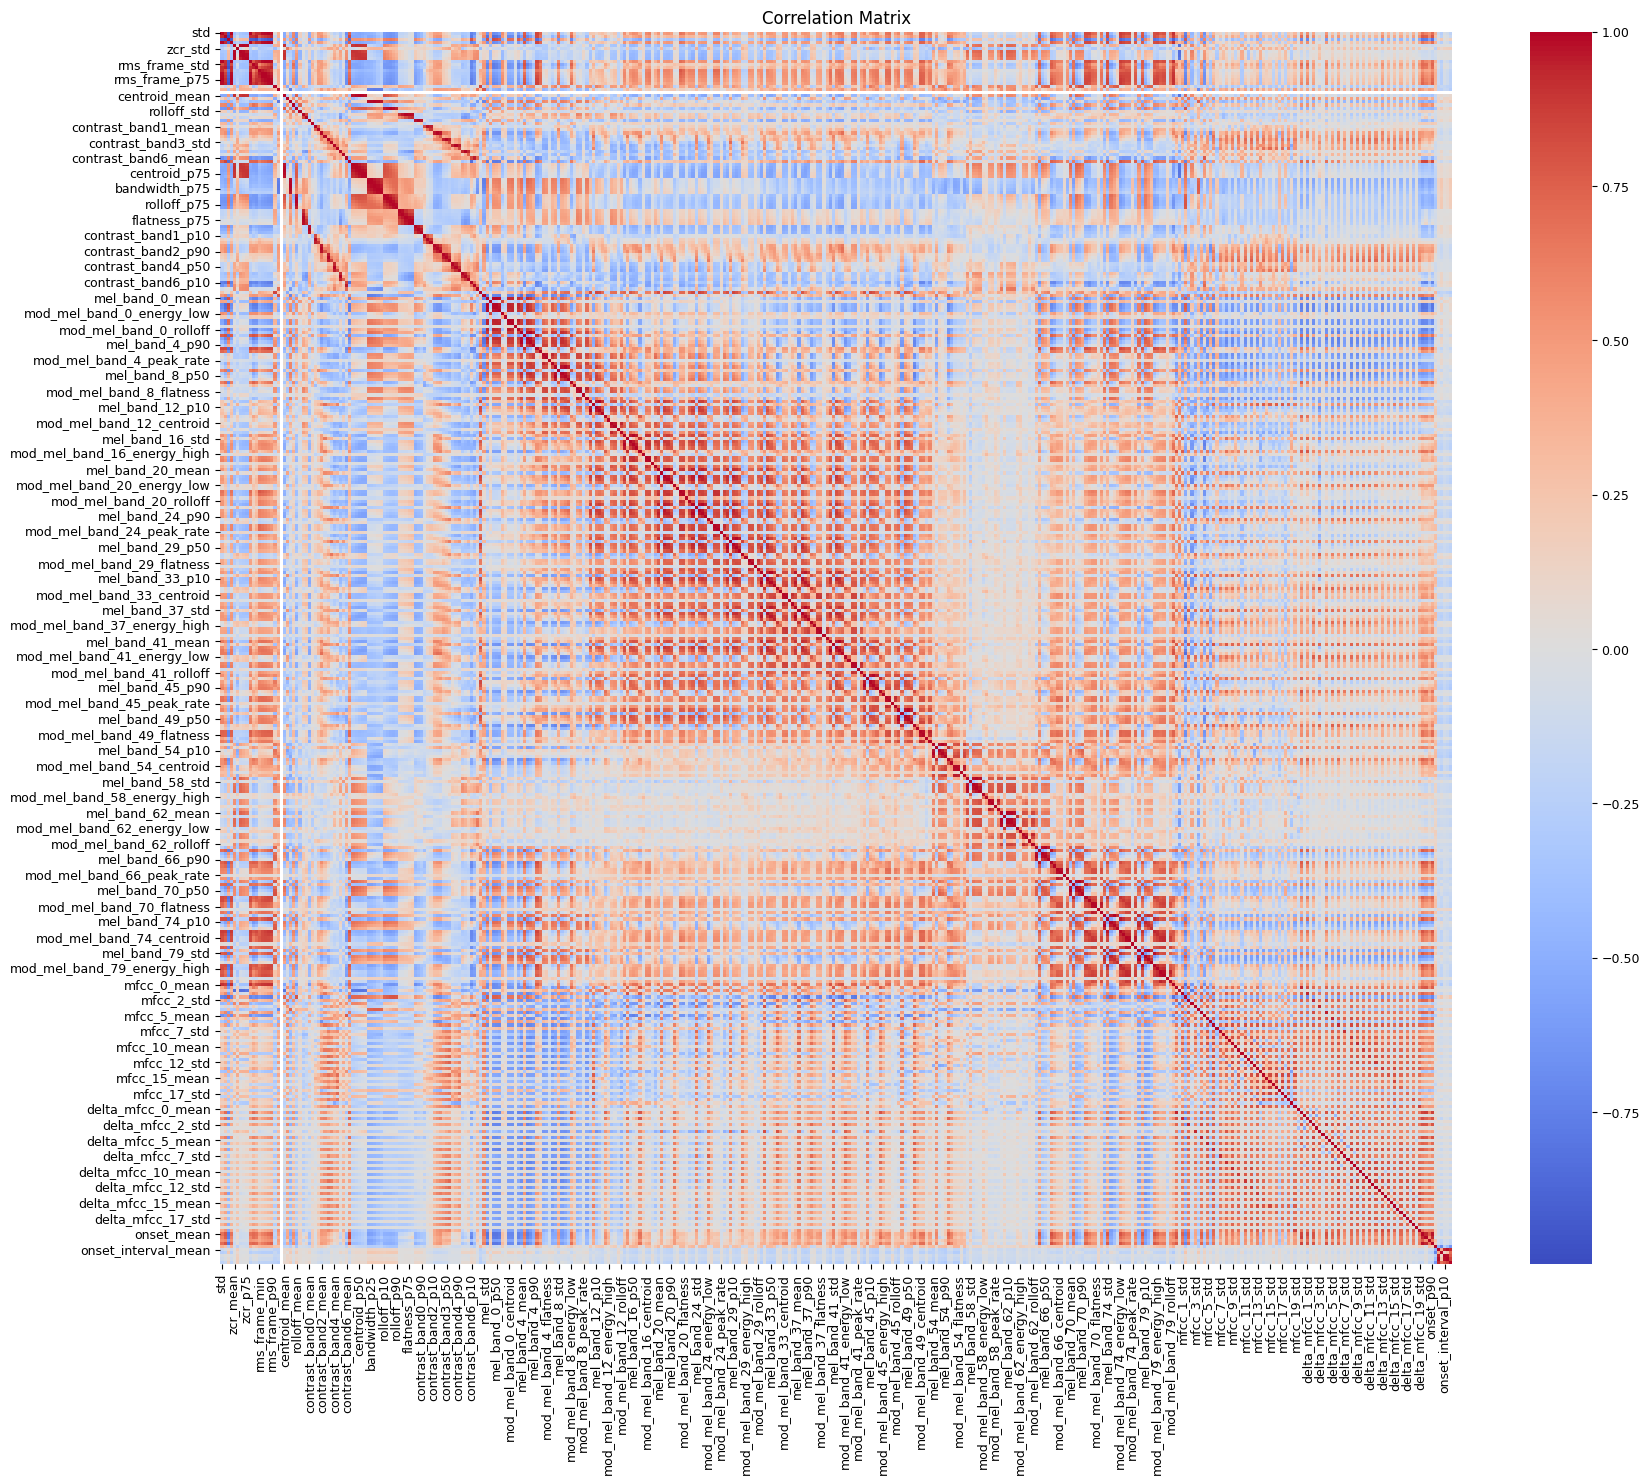

In [48]:
viz.plot_corr_matrix(corr_matrix)

We can see some "boxes" of high correlation usually around the same type of features (e.g. `mode_mel_band`). Let's let's see what are the most correlated variables

In [49]:
# Flatten correlation matrix into pairs
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs = corr_pairs.dropna()

# Rename columns
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

# Sort by absolute correlation (strongest first)
corr_pairs = corr_pairs.reindex(
    corr_pairs["correlation"].abs().sort_values(ascending=False).index
)

corr_pairs

,feature_1,feature_2,correlation
3,std,rms,1.000000e+00
33663,mel_band_0_mean,mel_band_0_p50,9.992545e-01
103359,mel_band_66_mean,mel_band_66_p50,9.984048e-01
99003,mel_band_62_mean,mel_band_62_p50,9.983777e-01
1587,zcr_mean,zcr_p50,9.983374e-01
...,...,...,...
140983,delta_mfcc_5_std,delta_mfcc_9_mean,-8.477627e-06
48042,mel_band_12_p50,mod_mel_band_58_flatness,8.200518e-06
10258,rolloff_std,delta_mfcc_19_mean,6.651074e-06
60253,mel_band_24_std,mod_mel_band_45_centroid,4.642253e-06


In [50]:
(corr_pairs["correlation"] > 0.90).sum()

np.int64(432)

We can look into doing something like correlation filtering in order to remove features that are too correlated. Depending on the type of model we use later this can help.

In [51]:
# viz.plot_feature_distribution(data_train_soundscapes, "mean")

It is strange that the means are in such clear bands. This may be an artifact to the different recording stations that may not carry over well into the test dataset.

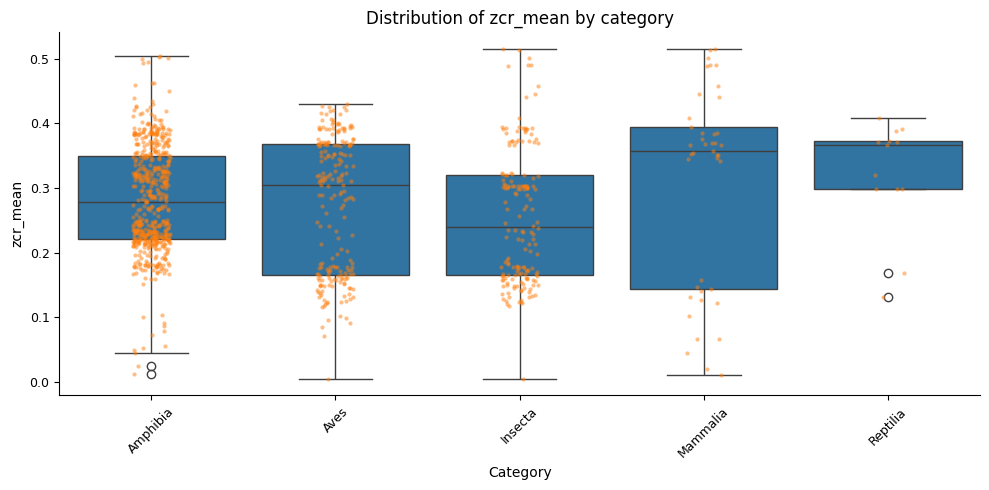

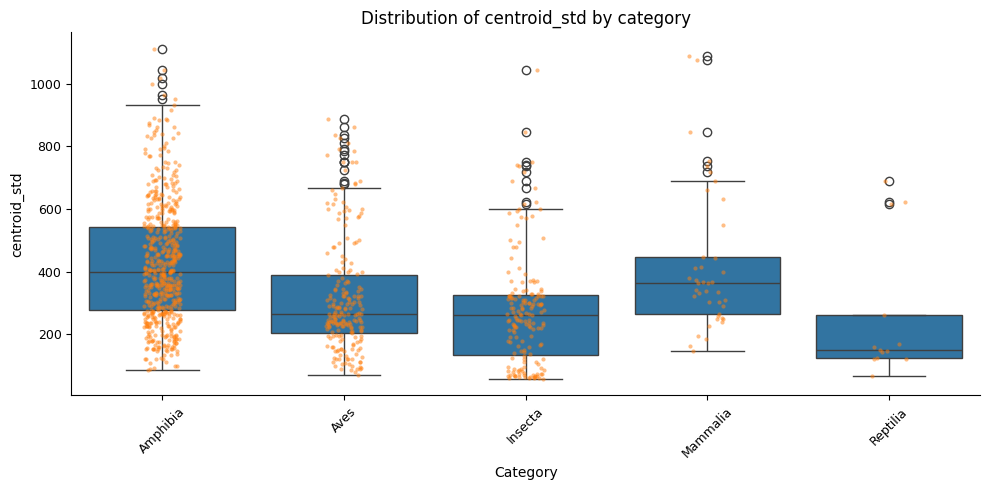

In [52]:
viz.plot_feature_distribution(data_train_soundscapes, "zcr_mean")
viz.plot_feature_distribution(data_train_soundscapes, "centroid_std")

Principle Component Analysis

In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Features
X = data_train_soundscapes["X"]

# Labels
y = data_train_soundscapes["y_class"]

# Standardize features (VERY important for PCA)
X_scaled = StandardScaler().fit_transform(X)

# PCA to 10 dimensions
pca = PCA(n_components=10)

X_pca = pca.fit_transform(X_scaled)

In [54]:
print(
    f"Explained Variance Ratio with 10 dimensions: {pca.explained_variance_ratio_.sum():.2f}"
)

Explained Variance Ratio with 10 dimensions: 0.71


With multiple labels split into differe

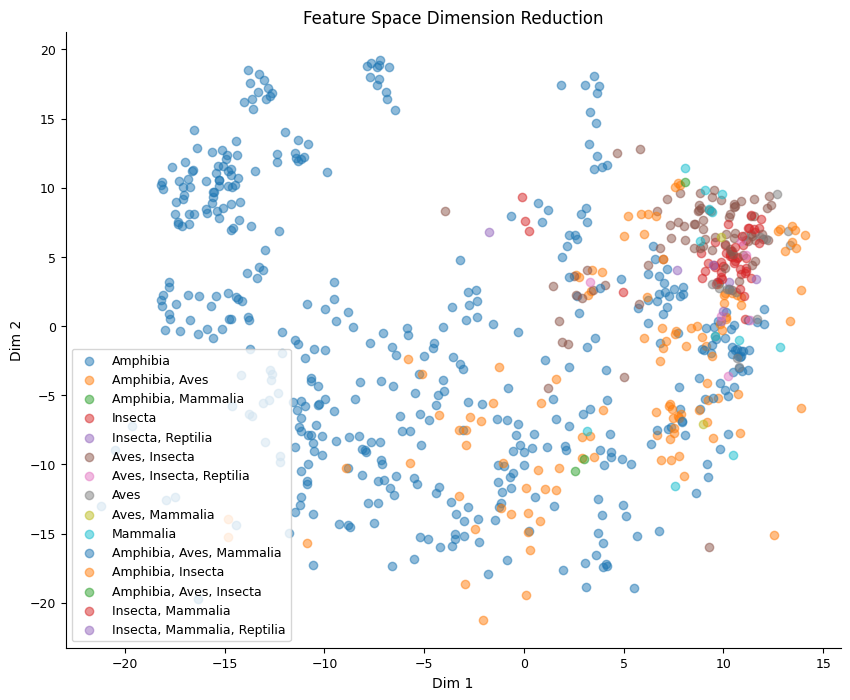

In [55]:
viz.plot_dim_reduction(X_pca, y, all_class_combinations=True)

PCA Circle

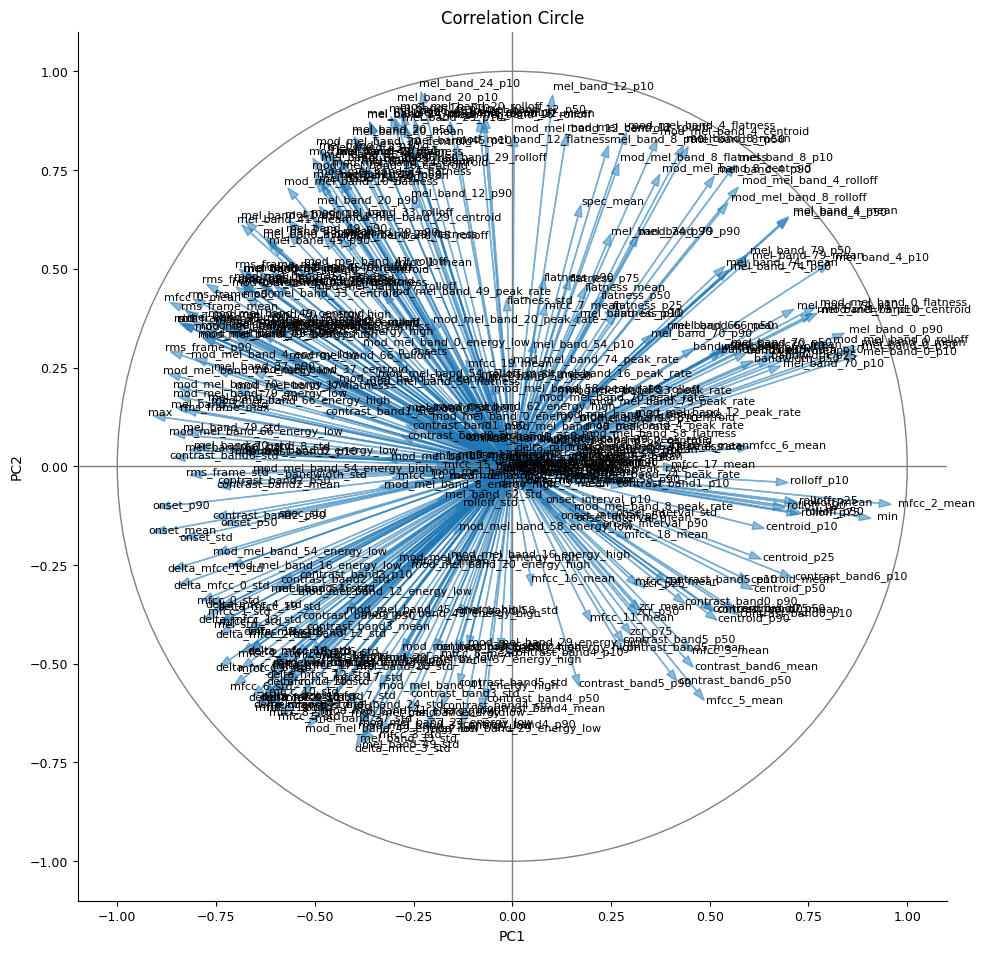

In [56]:
viz.plot_corr_cirle(X,pca)

# UMAP

In [57]:
from sklearn.manifold import TSNE, Isomap
X_embeddigs = TSNE(perplexity=30).fit_transform(X_scaled)

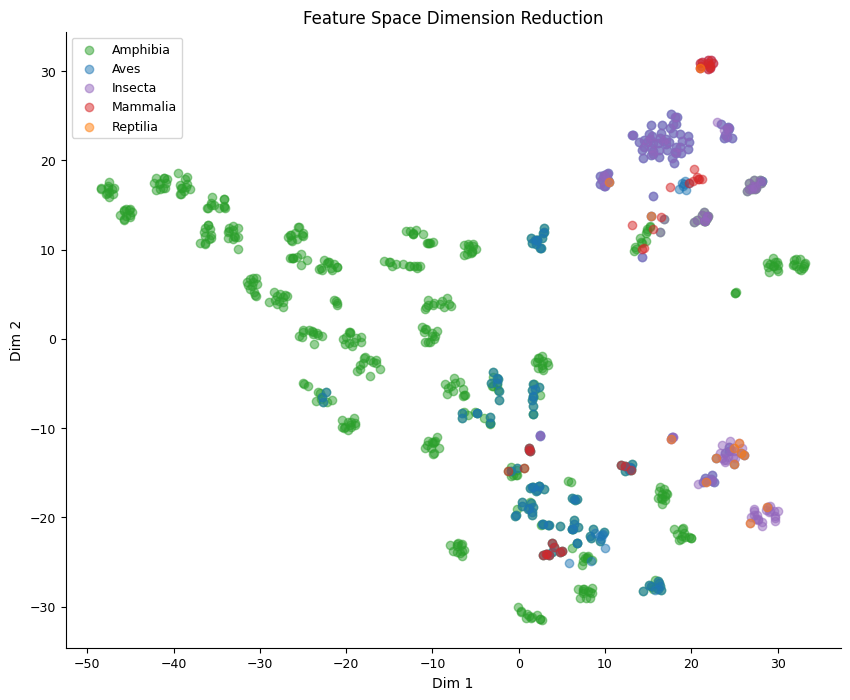

In [58]:
viz.plot_dim_reduction(X_embeddigs, y, all_class_combinations=False)

# Check which species are close to Pantanal

6574 / 35549 selected


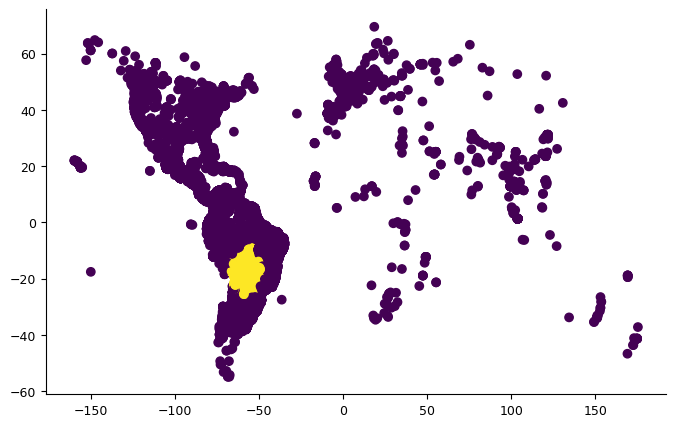

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97710/3370963405.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  counts_train = data_train["y_primary"][df["relevant_location"]].sum(axis=0) / data_train["y_primary"].sum(axis=0)


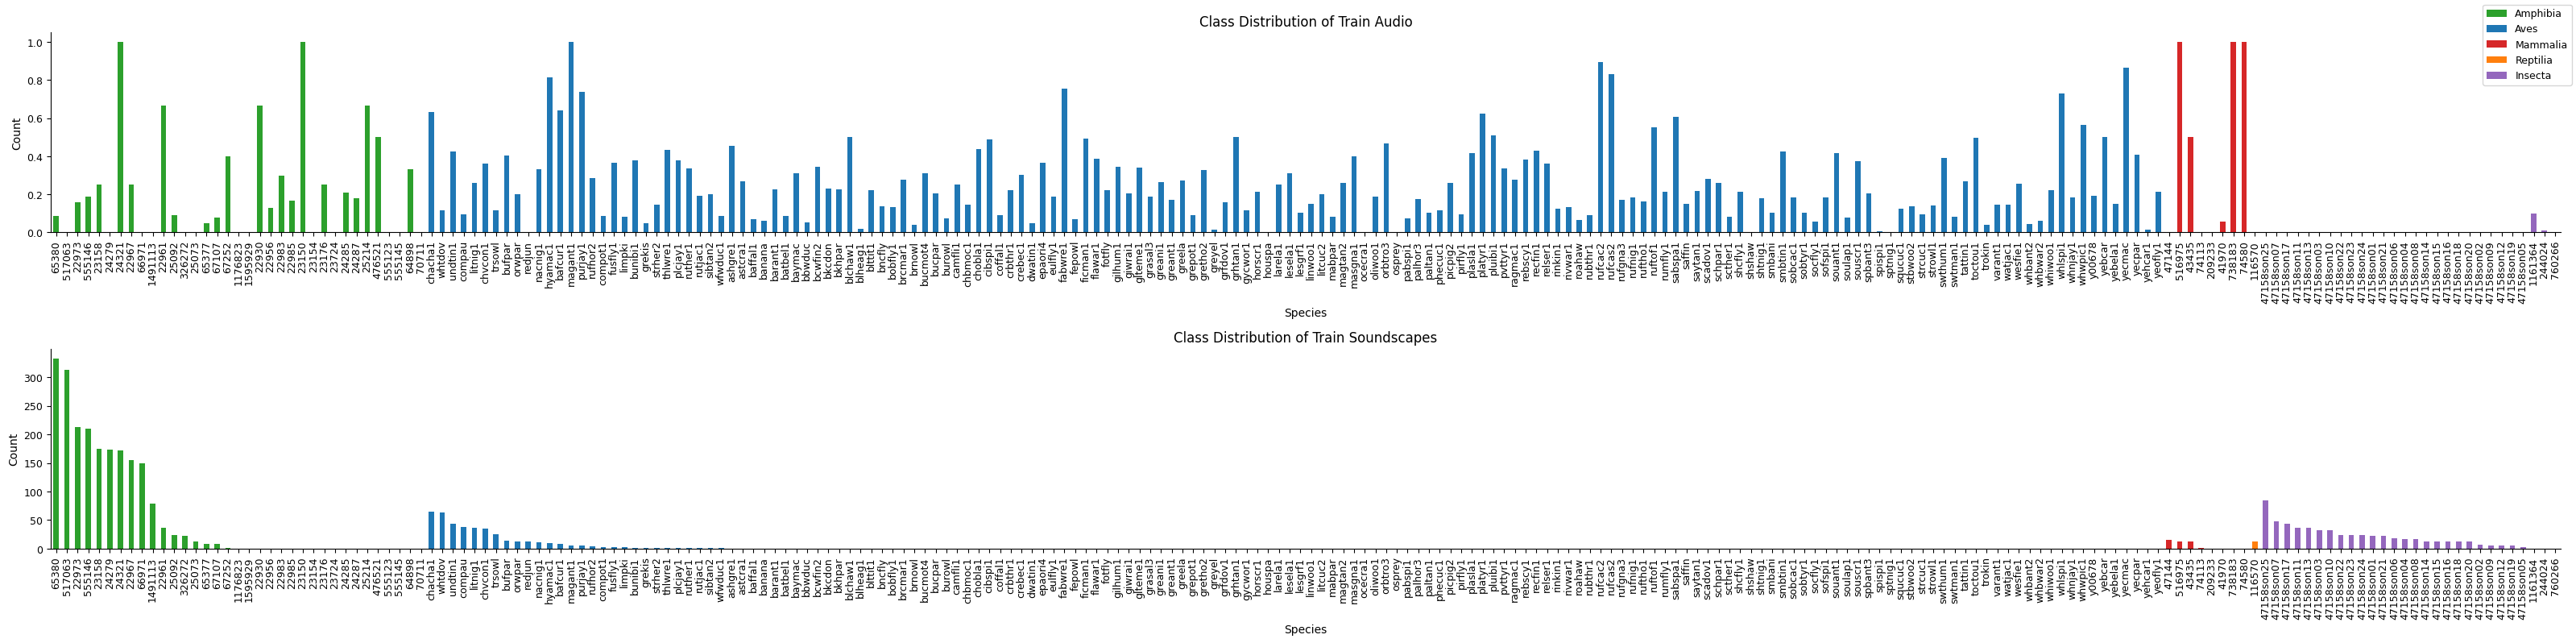

In [59]:
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt
from bioacoustics.data import load_metadata

df = data_train["metadata"].copy()

# Pantanal centroid (approx)
pantanal_center = (-17.5, -57.5)
GEO_RADIUS = 1000
def close_to_pantanal(lat, lon, threshold_km=GEO_RADIUS):
    return geodesic((lat, lon), pantanal_center).km < threshold_km

df["relevant_location"] = df.apply(lambda r: close_to_pantanal(r["latitude"], r["longitude"]), axis=1)
print(f"{df["relevant_location"].sum()} / {len(df)} selected")


plt.scatter(df["longitude"], df["latitude"], c=df["relevant_location"])
plt.show()
counts_train = data_train["y_primary"][df["relevant_location"]].sum(axis=0) / data_train["y_primary"].sum(axis=0)
counts_sound = data_train_soundscapes["y_primary"].sum(axis=0)

_, _, df_taxonomy = load_metadata()
primary_to_class = dict(zip(df_taxonomy["primary_label"], df_taxonomy["class_name"]))
viz.plot_species_distribution(counts_train, counts_sound, primary_to_class)